In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scikit_posthocs import posthoc_dunn
from scipy.stats import f_oneway, kruskal

from statannotations.Annotator import Annotator

sns.set_context("notebook", font_scale=1.5)  # Adjust font_scale to increase font size



# Analyse CFU data from community assembly 1

## Read in data

In [3]:
data_folder = Path("../../data/1_first_community_assembly")
file_to_open = data_folder / "cfus.csv"
df = pd.read_csv(file_to_open, index_col=0)

In [4]:
wellmap_fn = data_folder / "wellmap.csv"
wellmap_df = pd.read_csv(wellmap_fn, index_col=0)
wellmap_df['Carbon source'] = wellmap_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()
well_to_cs = wellmap_df.set_index('Well').to_dict()['Carbon source']
well_to_rep = wellmap_df.set_index('Well').to_dict()['Replicate']

In [5]:
palette = sns.palettes.color_palette('tab10')
palette = [palette[i] for i in [2,1,0,3]]

In [6]:
strains = ['At', 'Ct', 'Ml', 'Oa']

In [7]:
df['Carbon source'] = df['Carbon source'].str.replace('L-', '').str.replace('D-','')


In [8]:
cs_class_fn = '../../data/4_growth_phenotyping/carbon_sources.csv'
cs_class_df = pd.read_csv(cs_class_fn, index_col=0)
cs_class_df['Carbon source'] = cs_class_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()

cs_to_class = cs_class_df.set_index('Carbon source').to_dict()['Class']
# well_to_cs_type = {well:cs_to_cs_type[cs] for well, cs in cs_class_df.items() if not '+' in cs and not (cs == 'No CS')}

## Define functions


In [9]:
def shannon(l):
    x_tot = np.sum(l)
    p = l/x_tot
    return -np.sum([pi*np.log2(pi) for pi in p])

def simpson(l):
    x_tot = np.sum(l)
    p = l/x_tot
    return np.sum([pi*pi for pi in p])

def auxotroph_abundance(l_dict):
    x_tot =np.sum(list(l_dict.values()))
    x_aux = max(l_dict['Oa'],l_dict['Ml'])
    # print(l_dict, x_tot, x_aux)
    return x_aux/x_tot
    
def prototroph_abundance(l_dict):
    x_tot =np.sum(list(l_dict.values()))
    x_aux = max(l_dict['At'],l_dict['Ct'])
    # print(l_dict, x_tot, x_aux)
    return x_aux/x_tot


In [10]:
wells = [x for x in df.Well.unique() if x!= 'Inoculum']
strains = ['At', 'Ct', 'Ml', 'Oa']
shannon_dict = {}
simpson_dict = {}
auxotroph_dict = {}
prototroph_dict = {}
for w in wells:
    dfw = df.loc[(df.Well==w)&(df.Batch.isin([7,8]))]
    abundance = {}
    for strain in strains:
        dfws = dfw.loc[dfw.Strain == strain]
        abundance[strain] = dfws['CFUs/mL'].mean()
    # print(w)
    shannon_dict[w] = shannon(list(abundance.values()))
    simpson_dict[w] = simpson(list(abundance.values()))
    auxotroph_dict[w] = auxotroph_abundance(abundance)
    prototroph_dict[w] = prototroph_abundance(abundance)

In [87]:
shannon_df = pd.DataFrame(index = wells)
shannon_df['Shannon index'] = shannon_df.index.map(shannon_dict)
shannon_df['Simpson index'] = shannon_df.index.map(simpson_dict)
shannon_df['Auxotroph index'] = shannon_df.index.map(auxotroph_dict)
shannon_df['Prototroph index'] = shannon_df.index.map(prototroph_dict)
shannon_df['CS'] = shannon_df.index.map(well_to_cs)
shannon_df['CS class'] = shannon_df.CS.map(cs_to_class)
shannon_df = shannon_df.loc[~shannon_df['Shannon index'].isna()].copy()
shannon_df['N CS'] = [2 if '+' in cs else 1 for cs in shannon_df['CS']]
shannon_df.loc[shannon_df['N CS']==2, 'CS class'] = 'Mix'


In [88]:
for i, row in shannon_df.iterrows():
    if isinstance(row['CS'], str):
        if  '+' in row['CS']:
            shannon_df.at[i, 'N CS'] = 2
        elif row['CS'] == 'No CS':
            shannon_df.at[i, 'N CS'] = 0    
        else:
            shannon_df.at[i, 'N CS'] = 1
    else:
        shannon_df.at[i, 'N CS'] = np.nan

In [89]:
len(shannon_df.loc[shannon_df['N CS'] == 1])    

48

## Group by cs class

[Text(0, 0.5, 'Shannonn diversity')]

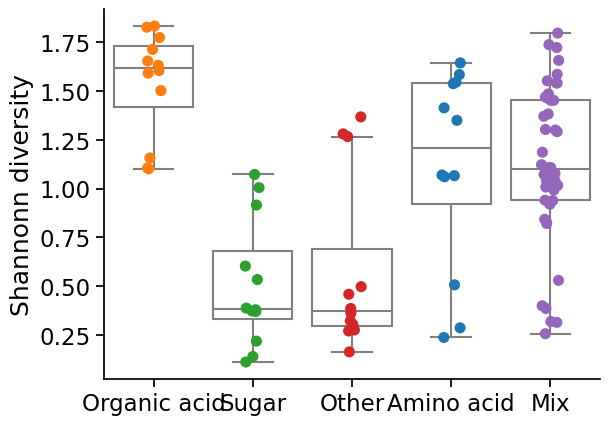

In [93]:
# idx = shannon_df['N CS'] == 1
ax = sns.boxplot(shannon_df, x = 'CS class', y = 'Shannon index',
                #  hue = 'CS class', 
                #  boxprops = {'facecolor':'none'},
                color = 'w',
                 legend=False,
                 linecolor='grey',
                    linewidth=1.5, 
                 fliersize=0)

# for patch in ax.patches:
#     r, g, b, a = patch.get_facecolor()
#     patch.set_facecolor((r, g, b, .3))

# Add in points to show each observation
sns.stripplot(shannon_df, x = 'CS class', y = 'Shannon index', 
              size=8, 
              hue = 'CS class',
              hue_order=['Amino acid', 'Organic acid', 'Sugar', 'Other', 'Mix'],
            #   color = 'k'
              )#, color=".3")
# sns.move_legend(ax, loc = 1, bbox_to_anchor = (0.9,0.6,0.4,0.4))
sns.despine()
ax.set(xlabel='')
ax.set(ylabel='Shannonn diversity')


In [94]:
shannon_df['y'] = shannon_df['Shannon index']
shannon_df['csx'] = shannon_df['CS class']  

In [96]:

# Group the data by 'CS class' and extract the 'Shannon index' values for each group
# groups = [group['Shannon index'].values for name, group in shannon_df.loc[shannon_df['N CS']==1].groupby('CS class')]
groups = [group['Shannon index'].values for name, group in shannon_df.groupby('CS class')]

# Perform one-way ANOVA
f_stat, p_value = kruskal(*groups)

# Print the results
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

F-statistic: 36.04429955006481
P-value: 2.833605569979313e-07


In [97]:
shannon_df['CS class'] = shannon_df['CS class'].astype(str)

In [109]:

# posthoc dunn test, with correction for multiple testing
dunn_df = posthoc_dunn(
    shannon_df, val_col="y", group_col="csx", p_adjust="fdr_bh"
)
dunn_df
remove = np.tril(np.ones(dunn_df.shape), k=0).astype("bool")
dunn_df[remove] = np.nan

molten_df = dunn_df.melt(ignore_index=False).reset_index().dropna()
molten_df

,index,variable,value
5,Amino acid,Mix,0.994440
10,Amino acid,Organic acid,0.023340
11,Mix,Organic acid,0.006105
15,Amino acid,Other,0.023340
16,Mix,Other,0.006105
17,Organic acid,Other,0.000011
20,Amino acid,Sugar,0.008564
21,Mix,Sugar,0.001422
22,Organic acid,Sugar,0.000002
23,Other,Sugar,0.728279


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Organic acid vs. Sugar: Custom statistical test, P_val:2.305e-06
Organic acid vs. Other: Custom statistical test, P_val:1.141e-05


/Users/snorre/miniconda3/lib/python3.12/site-packages/statannotations/Annotator.py:786: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_95587/2221936501.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='center')


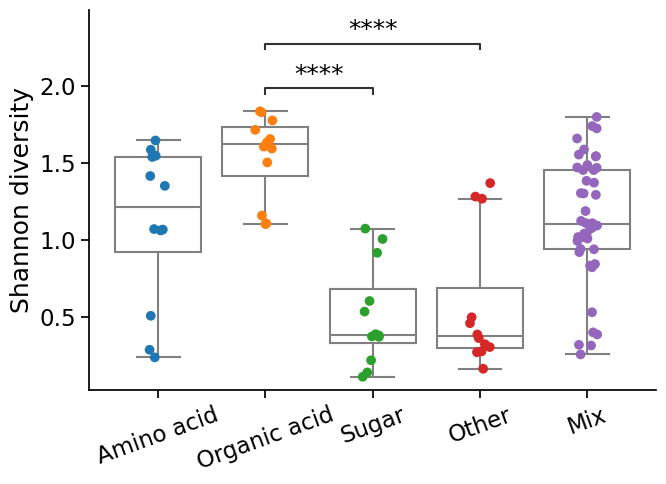

In [111]:
from statannotations.Annotator import Annotator
# cs_classes = shannon_df.loc[idx, 'CS class'].unique()
cs_classes = ['Amino acid', 'Organic acid', 'Sugar', 'Other', 'Mix']

# idx = shannon_df['N CS'] == 1
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(shannon_df, x = 'CS class', y = 'Shannon index',
                #  hue = 'CS class', 
                #  boxprops = {'facecolor':'none'},
                color = 'w',
                 legend=False,
                 linecolor='grey',
                    linewidth=1.5, 
                 fliersize=0,
                 order = cs_classes,
                 ax = ax)

# for patch in ax.patches:
#     r, g, b, a = patch.get_facecolor()
#     patch.set_facecolor((r, g, b, .3))

# Add in points to show each observation
sns.stripplot(shannon_df, x = 'CS class', y = 'Shannon index', 
              size=7, 
              hue = 'CS class',
              hue_order=cs_classes,
            #   color = 'k'
              )


pairs = [(i[1]["index"], i[1]["variable"]) for i in molten_df.iterrows()]
p_values = [i[1]["value"] for i in molten_df.iterrows()]

annotator = Annotator(
    ax, pairs, data=shannon_df, x="csx", y="y", order=cs_classes, #orient="h" 
)
# plt.ylim(0,2)
annotator.configure(text_format="star", loc="inside",
    hide_non_significant=True, alpha=0.001)
annotator.set_pvalues_and_annotate(p_values)
sns.despine()
plt.tight_layout()
ax.set_ylabel('Shannon diversity')
ax.set_xlabel('')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='center')

plt.savefig("../../Figures/assembly_1_cs_class_boxplot_kruskal-wallis-posthoc.pdf")

In [ ]:
annotator.configure()

## Group by N CS

In [20]:

# Group the data by 'CS class' and extract the 'Shannon index' values for each group
idx2 = shannon_df['N CS'].isin([1,2])
groups = [group['Shannon index'].values for name, group in shannon_df.loc[idx2].groupby('N CS')]

# Perform one-way ANOVA
f_stat, p_value2 = kruskal(*groups)

# Print the results
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value2}")

F-statistic: 1.8936761229314243
P-value: 0.16878787348481414


In [21]:
ncs_name = {1: 'One', 2: 'Two'}
shannon_df['# Carbon sources'] = shannon_df['N CS'].map(ncs_name)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

One vs. Two: Custom statistical test, P_val:1.688e-01


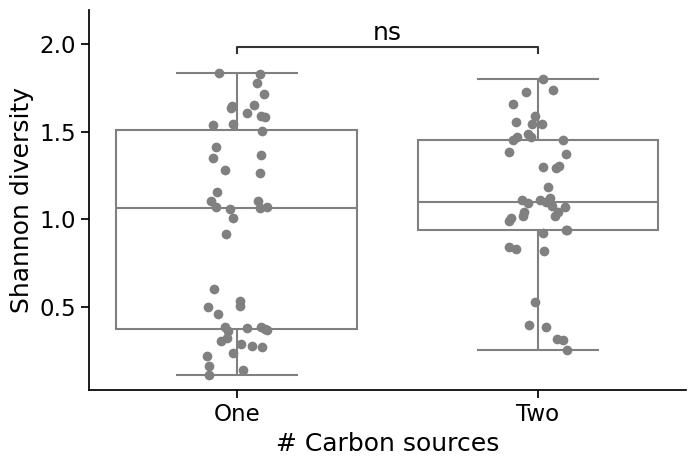

In [22]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(shannon_df.loc[idx2], x = '# Carbon sources', y = 'Shannon index',
                #  hue = 'CS class', 
                #  boxprops = {'facecolor':'none'},
                color = 'w',
                 legend=False,
                 linecolor='grey',
                    linewidth=1.5, 
                 fliersize=0,
                 ax=ax)

# for patch in ax.patches:
#     r, g, b, a = patch.get_facecolor()
#     patch.set_facecolor((r, g, b, .3))

# Add in points to show each observation
sns.stripplot(shannon_df.loc[idx2], x = '# Carbon sources', y = 'Shannon index', 
              size=7, 
              # hue = '# Carbon sources'
              color = 'grey'
              )#, color=".3")
# sns.move_legend(ax, loc = 1, bbox_to_anchor = (0.9,0.6,0.4,0.4))
sns.despine()
ax.set(ylabel='')


pairs = [['One','Two']]
# # pairs = [(i[1]["index"], i[1]["variable"]) for i in molten_df.iterrows()]
p_values = [p_value2]

annotator = Annotator(
    ax, pairs, data=shannon_df.loc[idx2], x='# Carbon sources', y="y", order=['One', 'Two'], #orient="h" 
)
annotator.configure(text_format="star", loc="inside",
    # hide_non_significant=True
    )
annotator.set_pvalues_and_annotate(p_values)

plt.tight_layout()
ax.set_ylabel('Shannon diversity')
plt.savefig("../../Figures/assembly_1_n_cs_boxplot_kruskal-wallis-posthoc.pdf")

## Group by auxotrophy

In [23]:
abundance_threshold = 0.1
shannon_df['Abundant auxotroph'] = shannon_df['Auxotroph index'] > abundance_threshold
shannon_df['Abundant prototroph'] = shannon_df['Prototroph index'] > abundance_threshold

groups = [group['Shannon index'].values for name, group in shannon_df.loc[idx2].groupby(['Abundant auxotroph', '# Carbon sources'])]

# Perform one-way ANOVA
f_stat, p_value3 = kruskal(*groups)
print(f_stat, p_value)

51.02905365771289 1.5035030283127793e-05


In [24]:
shannon_df['xxx'] = shannon_df['Abundant auxotroph'].astype(str)+ '/'+shannon_df['# Carbon sources']

In [25]:

# posthoc dunn test, with correction for multiple testing
dunn_df = posthoc_dunn(
    shannon_df.loc[idx2], val_col="y", group_col="xxx", p_adjust="fdr_bh"
)
dunn_df
remove = np.tril(np.ones(dunn_df.shape), k=0).astype("bool")
dunn_df[remove] = np.nan

molten_df2 = dunn_df.melt(ignore_index=False).reset_index().dropna()
molten_df2

,index,variable,value
4,False/One,False/Two,5.585622e-04
8,False/One,True/One,1.066055e-10
9,False/Two,True/One,3.683155e-03
12,False/One,True/Two,9.415157e-08
13,False/Two,True/Two,5.682190e-02
14,True/One,True/Two,3.507338e-01


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

One_False vs. One_True: Custom statistical test, P_val:1.066e-10
One_False vs. Two_False: Custom statistical test, P_val:5.586e-04


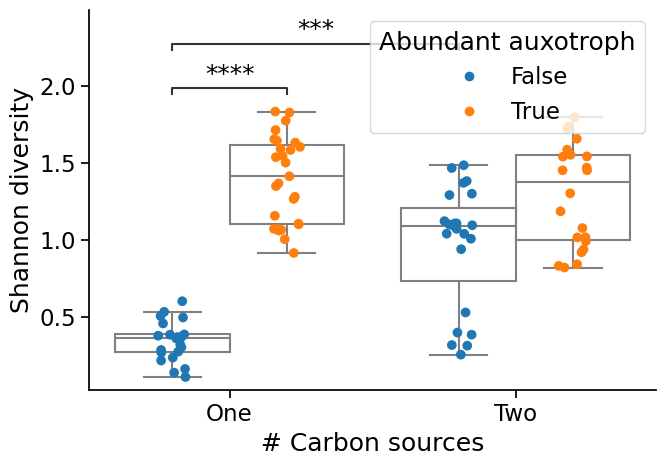

In [26]:

fig, ax = plt.subplots(figsize=(7,5))

sns.boxplot(shannon_df.loc[idx2], hue = 'Abundant auxotroph', y = 'Shannon index', x ='# Carbon sources', palette='tab10', legend=None, 
            color = 'w',
            dodge=True,
                 linecolor='grey',
                    linewidth=1.5, 
                 boxprops = {'facecolor':'none'},
                 ax=ax,
                 fliersize=0)#,)

# for patch in ax.patches:
#     r, g, b, a = patch.get_facecolor()
#     patch.set_facecolor((r, g, b, .3))

# Add in points to show each observation
ax = sns.stripplot(shannon_df.loc[idx2], hue = 'Abundant auxotroph', y = 'Shannon index', x = '# Carbon sources', size=7, palette='tab10', dodge=0.5, legend=True)#, color=".3")
# sns.move_legend(ax, loc = 1, bbox_to_anchor = (0.9,0.9,0.4,0.4), ncol=2)
sns.despine()

pairs = [(('One', False),('Two', False)),
         (('One', False),('One', True)),
        #  (('Two', False),('Two', True)),
         # (('One', True),('Two', False))
         ]
# # pairs = [(i[1]["index"], i[1]["variable"]) for i in molten_df.iterrows()]
p_values3 = molten_df2['value'].values[:2]

annotator = Annotator(
    ax, pairs, data=shannon_df.loc[idx2], x='# Carbon sources', y="y", 
    hue = 'Abundant auxotroph',
    order=['One', 'Two'], #orient="h" 
)
annotator.configure(text_format="star", loc="inside",
    # hide_non_significant=True
    )
annotator.set_pvalues_and_annotate(p_values3)

plt.tight_layout()
ax.set_ylabel('Shannon diversity')
plt.savefig("../../Figures/assembly_1_n_cs_and_abundant_auxotroph_boxplot_kruskal-wallis-posthoc.pdf")

# Abundant species

In [29]:
pca_df = pd.read_csv(data_folder / 'pca.csv', index_col=0)
well_to_at_rank = pca_df.to_dict()['At rank']

In [35]:
shannon_df['At rank'] = shannon_df.index.map(well_to_at_rank)
shannon_df['At rank 1'] = shannon_df['At rank'] == 1

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_95587/1054877936.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(shannon_df.loc[idx2], x = 'At rank 1', y = 'Shannon index',


Text(17.5, 0.5, 'Shannon diversity')

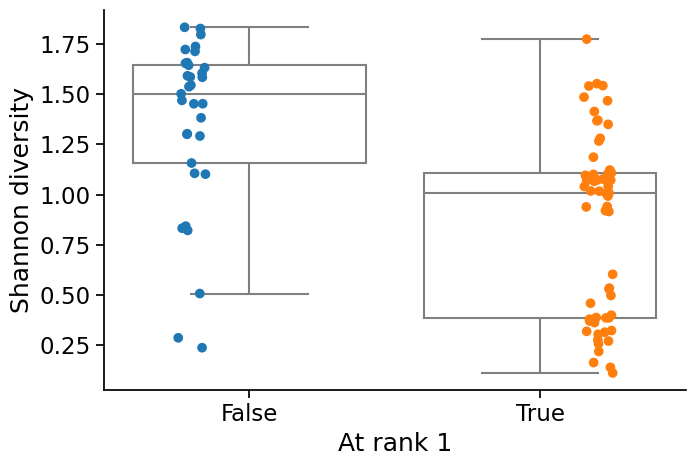

In [85]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(shannon_df.loc[idx2], x = 'At rank 1', y = 'Shannon index',
                # hue = 'Abundant auxotroph',
                color = 'w',
            dodge=True,
            legend=None,
                 linecolor='grey',
                    linewidth=1.5, 
                  boxprops = {'facecolor':'none'},
                  
                 fliersize=0,
                 ax=ax)

# for patch in ax.patches:
#     r, g, b, a = patch.get_facecolor()
#     patch.set_facecolor((r, g, b, .3))

# Add in points to show each observation
sns.stripplot(shannon_df.loc[idx2], x = 'At rank 1', y = 'Shannon index', 
              size=7, 
              # hue = 'Abundant auxotroph',
              palette='tab10',
              dodge=0.5,
            #   color = 'grey'
              )#, color=".3")
# sns.move_legend(ax, loc = 1, bbox_to_anchor = (0.9,0.6,0.4,0.4))
sns.despine()
ax.set(ylabel='')


pairs = [['One','Two']]
# # pairs = [(i[1]["index"], i[1]["variable"]) for i in molten_df.iterrows()]
p_values = [p_value2]

# annotator = Annotator(
#     ax, pairs, data=shannon_df.loc[idx2], x='# Carbon sources', y="y", order=['One', 'Two'], #orient="h" 
# )
# annotator.configure(text_format="star", loc="inside",
#     # hide_non_significant=True
#     )
# annotator.set_pvalues_and_annotate(p_values)

plt.tight_layout()
ax.set_ylabel('Shannon diversity')
# plt.savefig("../../Figures/assembly_1_n_cs_boxplot_kruskal-wallis-posthoc.pdf")

<Axes: xlabel='At rank 1', ylabel='Shannon index'>

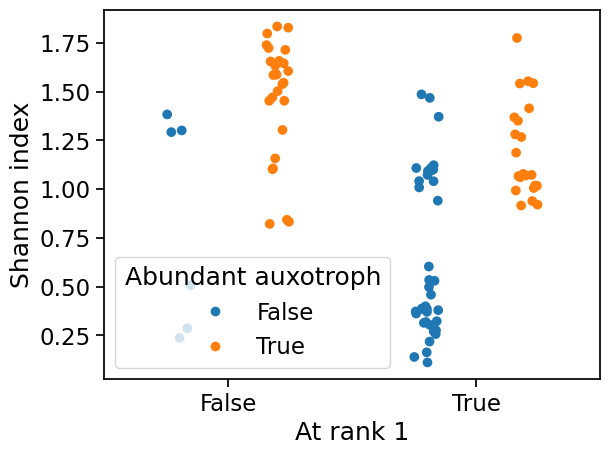

In [71]:
sns.stripplot(shannon_df, hue = 'Abundant auxotroph', y = 'Shannon index', x = 'At rank 1', dodge=0.5, size=7, palette='tab10', legend=True)

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_95587/2750877841.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(shannon_df.loc[(shannon_df['At rank 1'] == True)&(shannon_df['Abundant auxotroph']==False)], y = 'Shannon index', x = 'N CS', dodge=0.5, size=7, palette='tab10', legend=True)


<Axes: xlabel='N CS', ylabel='Shannon index'>

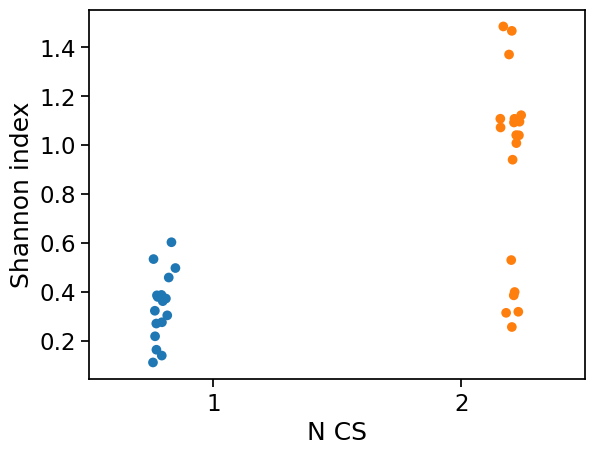

In [75]:
sns.stripplot(shannon_df.loc[(shannon_df['At rank 1'] == True)&(shannon_df['Abundant auxotroph']==False)], y = 'Shannon index', x = 'N CS', dodge=0.5, size=7, palette='tab10', legend=True)


In [77]:
shannon_df.loc[(shannon_df['At rank 1'] == True)&(shannon_df['Abundant auxotroph']==False)].sort_values(by='Shannon index', ascending=False)


,Shannon index,Simpson index,Auxotroph index,Prototroph index,CS,CS class,N CS,y,csx,# Carbon sources,Abundant auxotroph,Abundant prototroph,xxx,At rank,At dominant,At rank 1
G5,1.485417,0.440803,0.072948,0.607903,Ribose + glutarate,nan,2,1.485417,NaN,Two,False,True,False/Two,1,True,True
G4,1.467365,0.421806,0.091667,0.555556,Ribose + glutarate,nan,2,1.467365,NaN,Two,False,True,False/Two,1,True,True
G6,1.370698,0.455789,0.059190,0.591900,Ribose + glutarate,nan,2,1.370698,NaN,Two,False,True,False/Two,1,True,True
F11,1.122552,0.558568,0.028245,0.706120,Mannitol + acetate,nan,2,1.122552,NaN,Two,False,True,False/Two,1,True,True
F12,1.108019,0.550866,0.025967,0.692441,Mannitol + acetate,nan,2,1.108019,NaN,Two,False,True,False/Two,1,True,True
F4,1.107779,0.597477,0.067532,0.753247,Glutamate + mannose,nan,2,1.107779,NaN,Two,False,True,False/Two,1,True,True
G1,1.100858,0.579248,0.053461,0.731570,Myo-inositol + glutamate,nan,2,1.100858,NaN,Two,False,True,False/Two,1,True,True
G2,1.095929,0.569842,0.039483,0.717875,Myo-inositol + glutamate,nan,2,1.095929,NaN,Two,False,True,False/Two,1,True,True
G3,1.092829,0.575932,0.048411,0.726172,Myo-inositol + glutamate,nan,2,1.092829,NaN,Two,False,True,False/Two,1,True,True
F5,1.072336,0.611047,0.053672,0.762712,Glutamate + mannose,nan,2,1.072336,NaN,Two,False,True,False/Two,1,True,True
